In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import sys
import os
print('cwd=', os.getcwd())
print('sys.path[0]=', sys.path[0])
print('PROJECT_ROOT=', PROJECT_ROOT)
print('exists src?', os.path.isdir(os.path.join(PROJECT_ROOT, 'src')))
print('exists parameters.py?', os.path.isfile(os.path.join(PROJECT_ROOT, 'src', 'parameters.py')))
print('exists state_simulator.py?', os.path.isfile(os.path.join(PROJECT_ROOT, 'src', 'states', 'state_simulator.py')))
try:
    from src.states.state_simulator import StateSimulator
    print('import StateSimulator OK')
except Exception as e:
    print(type(e).__name__, e)

cwd= c:\Users\ce81g\strategy_allocation\notebooks
sys.path[0]= c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\python314.zip
PROJECT_ROOT= c:\Users\ce81g\strategy_allocation
exists src? True
exists parameters.py? True
exists state_simulator.py? True
import StateSimulator OK


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.states.state_simulator import StateSimulator

from src.simulation.environment import DeFiEnvironment

from src.simulation.monte_carlo import MonteCarloEngine

from src.portfolio.portfolio_engine import PortfolioEngine

from src.risk.risk_engine import RiskEngine

In [4]:
from src.strategies.lending import PassiveLending

from src.strategies.carry import LeveragedCarry

from src.strategies.amm import AMMLiquidityProvision

from src.strategies.basis import BasisArbitrage

from src.strategies.vol_selling import VolatilitySelling

from src.strategies.reflexive import ReflexiveYield

In [5]:
# Allocation Policies

from src.portfolio.allocation_policies import (

    CarryMaximizerPolicy,

    RegimeAdaptivePolicy,

    RobustGrowthPolicy,
)

In [6]:
# Risk Metrics

from src.risk.metrics import (

    compute_cagr,

    compute_log_growth,
)

from src.risk.drawdown import (

    compute_max_drawdown,

    compute_time_under_water,
)

from src.risk.volatility import (
    
    compute_volatility,
)

In [7]:

# 2. Experimental Configuration

## Monte Carlo Parameters
N_PATHS = 500

N_STEPS = 250

INITIAL_CAPITAL = 10_000

In [8]:
# 3. Strategy Universe
STRATEGIES = {

    "Passive Lending": PassiveLending(),

    "Leveraged Carry": LeveragedCarry(),

    "AMM Liquidity Provision": AMMLiquidityProvision(),

    "Basis Arbitrage": BasisArbitrage(),

    "Volatility Selling": VolatilitySelling(),

    "Reflexive Yield": ReflexiveYield(),
}

In [9]:
# 4. Shared System Components
state_simulator = StateSimulator()

portfolio_engine = PortfolioEngine()

risk_engine = RiskEngine()

In [10]:
# 5. Initial Market State
initial_state = state_simulator.generate_state(

    regime="carry",

    timestamp=0
)
strategies = {

    "passive_lending":
        PassiveLending(),

    "leveraged_carry":
        LeveragedCarry(),

    "amm_lp":
        AMMLiquidityProvision(),

    "basis_arbitrage":
        BasisArbitrage(),

    "volatility_selling":
        VolatilitySelling(),

    "reflexive_yield":
        ReflexiveYield(),
}

In [11]:
# 6. Policy Experiment Runner
def run_policy_experiment(state_simulator, policy, initial_state):

    environment = DeFiEnvironment(

        state_simulator=state_simulator,

        strategies=strategies,

        allocation_policy=policy,

        portfolio_engine=portfolio_engine,

        risk_engine=risk_engine,
    )

    mc_engine = MonteCarloEngine(environment)

    paths = mc_engine.run_many_paths(

    initial_state=initial_state,

    n_paths=N_PATHS,

    horizon=N_STEPS,

    initial_capital=INITIAL_CAPITAL,
)

    return paths

In [12]:
from src.states.state_simulator import (
    StateSimulator
)

simulator = StateSimulator()

print(simulator.regimes)

print(simulator.transition_matrix.shape)

['carry', 'stable_range', 'stress', 'panic']
(4, 4)


In [ ]:
# 7. Run Comparative Experiments
baseline_state_simulator = StateSimulator()
forced_state_simulator = StateSimulator()

# Increase stress -> panic transition probability by 20 percentage points
forced_transition_matrix = forced_state_simulator.transition_matrix.copy()
stress_idx = 2
panic_idx = 3

forced_transition_matrix[stress_idx, panic_idx] += 0.20
forced_transition_matrix[stress_idx, stress_idx] -= 0.20

forced_state_simulator.transition_matrix = forced_transition_matrix

initial_state = baseline_state_simulator.generate_state(

    regime="carry",

    timestamp=0
)

carry_paths = run_policy_experiment(

    baseline_state_simulator,

    CarryMaximizerPolicy(),

    initial_state,
)

adaptive_paths = run_policy_experiment(

    baseline_state_simulator,

    RegimeAdaptivePolicy(),

    initial_state,
)

robust_paths = run_policy_experiment(

    baseline_state_simulator,

    RobustGrowthPolicy(),

    initial_state,
)

# Forced transition risk experiment
carry_paths_forced = run_policy_experiment(

    forced_state_simulator,

    CarryMaximizerPolicy(),

    initial_state,
)

adaptive_paths_forced = run_policy_experiment(

    forced_state_simulator,

    RegimeAdaptivePolicy(),

    initial_state,
)

robust_paths_forced = run_policy_experiment(

    forced_state_simulator,

    RobustGrowthPolicy(),

    initial_state,
)



IndexError: index 4 is out of bounds for axis 1 with size 4

In [ ]:
# 8. Path Extraction Utilities
def extract_terminal_wealth(paths):

    return [

        path[-1].portfolio.capital

        for path in paths
    ]

def extract_portfolio_histories(paths):

    histories = []

    for path in paths:

        history = [

            step.portfolio.capital

            for step in path
        ]

        histories.append(history)

    return histories

In [ ]:
# 9. Aggregate Performance Metrics
def evaluate_policy(paths):

    terminal_wealth = extract_terminal_wealth(paths)

    histories = extract_portfolio_histories(paths)

    cagrs = []

    log_growths = []

    drawdowns = []

    volatilities = []

    underwater_times = []

    for history in histories:

        cagrs.append(
            compute_cagr(history)
        )

        log_growths.append(
            compute_log_growth(history)
        )

        drawdowns.append(
            compute_max_drawdown(history)
        )

        volatilities.append(
            compute_volatility(history)
        )

        underwater_times.append(
            compute_time_under_water(history)
        )

    results = {

        "mean_terminal_wealth":
            np.mean(terminal_wealth),

        "median_terminal_wealth":
            np.median(terminal_wealth),

        "mean_cagr":
            np.mean(cagrs),

        "mean_log_growth":
            np.mean(log_growths),

        "mean_drawdown":
            np.mean(drawdowns),

        "mean_volatility":
            np.mean(volatilities),

        "mean_time_under_water":
            np.mean(underwater_times),
    }

    return results

In [ ]:
# 10. Evaluate All Policies
carry_results = evaluate_policy(carry_paths)

adaptive_results = evaluate_policy(adaptive_paths)

robust_results = evaluate_policy(robust_paths)

carry_results_forced = evaluate_policy(carry_paths_forced)

adaptive_results_forced = evaluate_policy(adaptive_paths_forced)

robust_results_forced = evaluate_policy(robust_paths_forced)


In [ ]:
# 11. Comparative Results Table

baseline_comparison = pd.DataFrame({

    "CarryMaximizer":
        carry_results,

    "RegimeAdaptive":
        adaptive_results,

    "RobustGrowth":
        robust_results,
})

forced_comparison = pd.DataFrame({

    "CarryMaximizer_Forced":
        carry_results_forced,

    "RegimeAdaptive_Forced":
        adaptive_results_forced,

    "RobustGrowth_Forced":
        robust_results_forced,
})

comparison_df = pd.concat([baseline_comparison, forced_comparison], axis=1)

comparison_df

,CarryMaximizer,RegimeAdaptive,RobustGrowth,CarryMaximizer_Forced,RegimeAdaptive_Forced,RobustGrowth_Forced
mean_terminal_wealth,59634.850352,1.408648e+06,6.439636e+07,17311.803387,1.060192e+06,6.013173e+07
median_terminal_wealth,2.936792,3.328672e+05,2.227852e+07,0.308779,2.107758e+05,1.059162e+07
mean_cagr,-0.033708,1.358247e-02,3.065012e-02,-0.041757,1.155791e-02,2.758527e-02
mean_log_growth,-0.034703,1.351789e-02,3.028850e-02,-0.043176,1.150452e-02,2.728744e-02
mean_drawdown,-0.995499,-6.821618e-01,-5.194291e-01,-0.996636,-7.267329e-01,-5.927336e-01
mean_volatility,0.139482,5.484803e-02,4.805367e-02,0.147212,5.567477e-02,5.139317e-02
mean_time_under_water,225.394000,1.639360e+02,1.065300e+02,229.596000,1.710960e+02,1.191140e+02


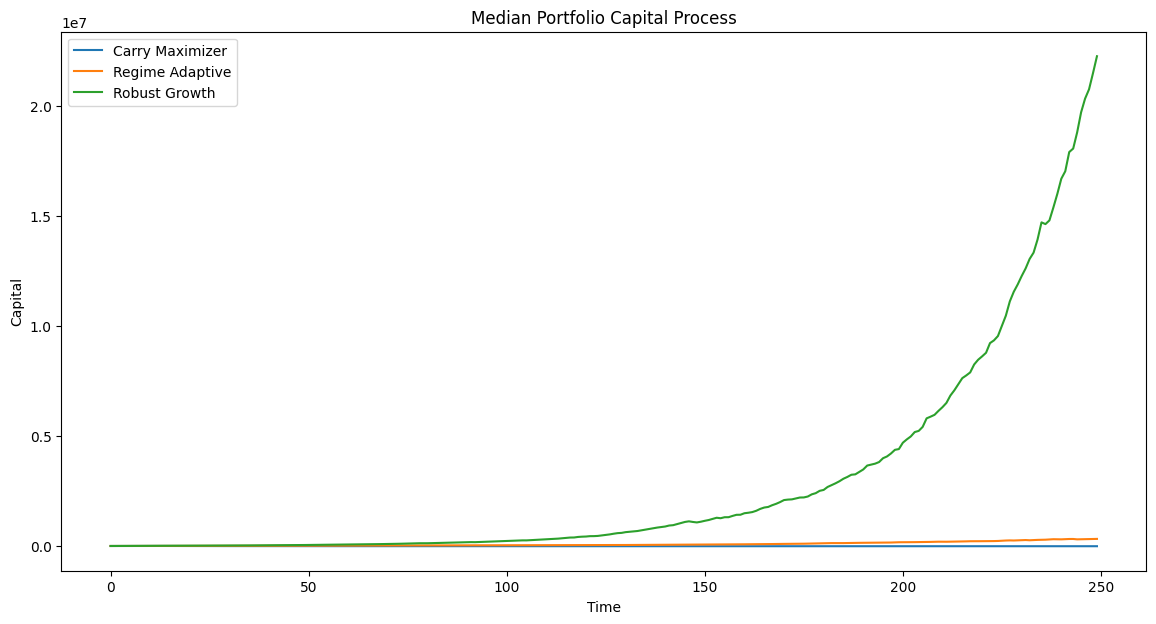

In [ ]:
# 12. Median Capital Path Visualization

def median_path(histories):

    return np.median(
        np.array(histories),
        axis=0
    )

carry_histories = extract_portfolio_histories(
    carry_paths
)

adaptive_histories = extract_portfolio_histories(
    adaptive_paths
)

robust_histories = extract_portfolio_histories(
    robust_paths
)

plt.figure(figsize=(14, 7))

plt.plot(

    median_path(carry_histories),

    label="Carry Maximizer"
)

plt.plot(

    median_path(adaptive_histories),

    label="Regime Adaptive"
)

plt.plot(

    median_path(robust_histories),

    label="Robust Growth"
)

plt.title("Median Portfolio Capital Process")

plt.xlabel("Time")

plt.ylabel("Capital")

plt.legend()

plt.show()

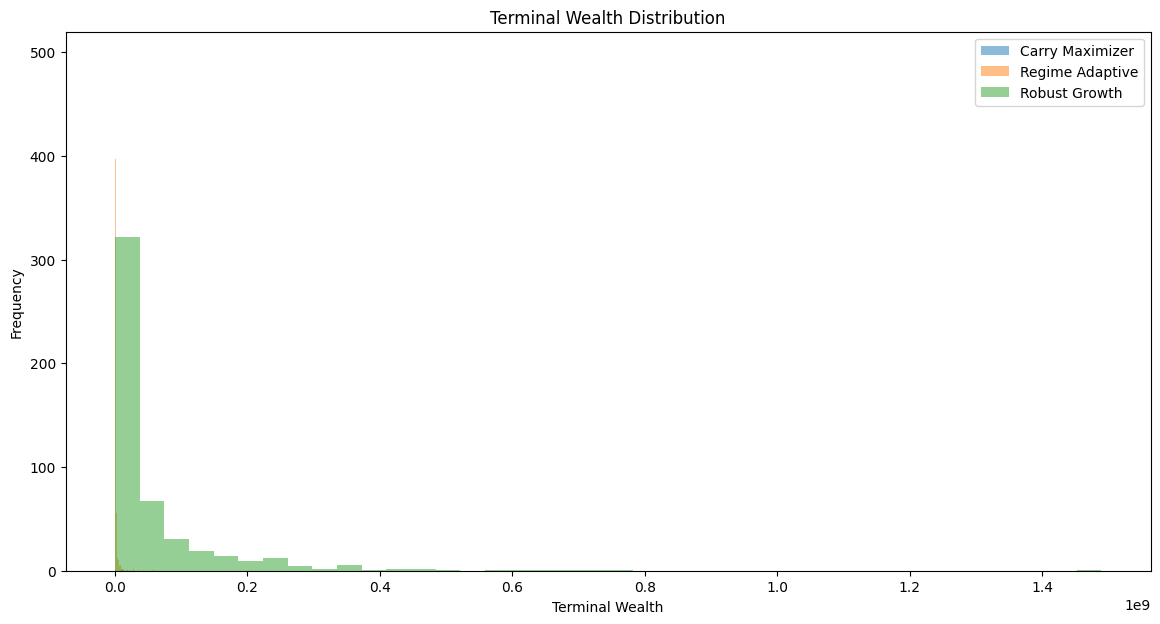

In [ ]:
# 13. Terminal Wealth Distribution
plt.figure(figsize=(14, 7))
plt.hist(

    extract_terminal_wealth(carry_paths),

    bins=40,

    alpha=0.5,

    label="Carry Maximizer"
)
plt.hist(
    extract_terminal_wealth(adaptive_paths),

    bins=40,

    alpha=0.5,

    label="Regime Adaptive"
)
plt.hist(
    extract_terminal_wealth(robust_paths),

    bins=40,

    alpha=0.5,

    label="Robust Growth"
)
plt.title("Terminal Wealth Distribution")
plt.xlabel("Terminal Wealth")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:
from src.risk.fragility_score import (
    compute_fragility_score
)

test_metrics = {

    "mean_drawdown": -0.15,

    "mean_CVaR_5": -0.10,

    "ruin_probability": 0.02,

    "mean_panic_fraction": 0.12,

    "mean_time_under_water": 40
}

result = compute_fragility_score(
    test_metrics
)

result